<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%203/L10_Weight_Init_and_BatchNorm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=OiIVNcfruzE) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%203/NPTEL_Jul24_DL4CV_W03_P05.pdf)

In [1]:
# Week 3, Lecture 10: Improving Training of NN Part 2
from IPython.display import HTML, display

VIDEO_ID = "OiIVNcfruzE"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 3, Lecture 10: Weight Initialization and Batch Normalization

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§3.5 Improvements in Training of Neural Networks**.

This is the final lecture of the week.

Training a deep network well starts before the first gradient step: **where you
start on the error surface decides which minimum you can reach**. This notebook
makes that concrete. We watch a bad initialization freeze a network, derive the
right scale for random weights from a short variance argument, build the classic
Xavier and He initializers from scratch, and finish with Batch Normalization,
which keeps activations well-scaled *during* training.

**What you will learn**
- **The symmetry problem**: initialize every weight to the same constant and watch two hidden units stay identical forever (identical activations, identical gradients), so the network cannot learn diverse features. Random init breaks the symmetry.
- **Variance propagation**: forward a zero-mean unit-variance batch through a deep linear stack and see the activation variance explode or vanish, then derive that we need $n\,\mathrm{Var}(w) = 1$, i.e. scale weights by $1/\sqrt{n}$ (with $n$ the fan-in).
- **Xavier / Glorot** and **He** initializers, coded from scratch, verified against `torch.nn.init`, and shown to keep activations well-scaled across depth.
- **Batch Normalization** from scratch: normalize each feature over the mini-batch to zero mean and unit variance, then rescale with learnable $\gamma, \beta$. Train with vs without BN at a high learning rate and compare stability.

**How we teach it:** each idea is built from primitive tensors
first, then matched to the idiomatic PyTorch version (`nn.init`, `nn.BatchNorm1d`),
and we check that the two agree.

**How to run**  Everything is tiny (small nets, small batches, short training)
and runs in seconds on **Colab CPU or GPU** (no GPU needed). Run the setup cell
first, then go top to bottom.

**Contents**

1. Why initialization matters, and the symmetry problem
2. How large should random weights be? A variance argument
3. Xavier / Glorot and He initialization, from scratch
4. Batch Normalization from scratch

## Review

The previous lecture compared sigmoid, tanh, ReLU and its variants, tracing vanishing gradients and dying ReLUs back to the activation function. Activations are only half of what keeps a signal healthy through depth. This lecture covers the other half: where the weights start, and how to keep activations well-scaled during training.

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and local Jupyter.
import sys, subprocess
# ipywidgets ships with Colab; install only if it is missing.
try:
    import ipywidgets  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, FloatSlider, IntSlider, Dropdown, Checkbox, fixed
%matplotlib inline

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)

# Use a GPU if one is available, otherwise CPU. Every demo here is tiny and
# runs in seconds on CPU, so no GPU is required.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True

print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.8.0 | device: cpu


## A tiny shared dataset

Several demos train a small classifier, so we make one lightweight 2D dataset up
front: `make_moons` from scikit-learn (no download, it is generated in memory).
We **standardize** the inputs to zero mean and unit variance per feature, which
is exactly the regime the initialization analysis below assumes.

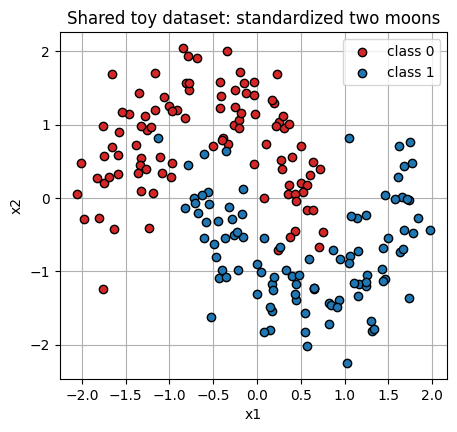

inputs: torch.Size([200, 2]) | per-feature mean ~ [-0.  0.] | per-feature std ~ [1.003 1.003]


In [3]:
from sklearn.datasets import make_moons

X_np, y_np = make_moons(n_samples=200, noise=0.2, random_state=0)
X_np = (X_np - X_np.mean(axis=0)) / X_np.std(axis=0)   # standardize per feature

X_moons = torch.tensor(X_np, dtype=torch.float32, device=device)
y_moons = torch.tensor(y_np, dtype=torch.float32, device=device).unsqueeze(1)

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.scatter(X_np[y_np == 0, 0], X_np[y_np == 0, 1], c="tab:red", edgecolor="k", label="class 0")
ax.scatter(X_np[y_np == 1, 0], X_np[y_np == 1, 1], c="tab:blue", edgecolor="k", label="class 1")
ax.set_xlabel("x1"); ax.set_ylabel("x2")
ax.set_title("Shared toy dataset: standardized two moons")
ax.legend(loc="best")
plt.show()

print("inputs:", X_moons.shape, "| per-feature mean ~", X_moons.mean(0).cpu().numpy().round(3),
      "| per-feature std ~", X_moons.std(0).cpu().numpy().round(3))

## 1. Why initialization matters, and the symmetry problem

Recall the neural-network **error surface**. It is non-convex, so *where you
start* is critical to which local minimum you reach. The first question the
slide asks: what if we initialize all weights to **zero** (or any constant)?

**Any constant initialization performs very poorly.** Take a hidden layer with
two units and ReLU, biases $0$, all weights set to a constant $\alpha$. Forward
propagate an input $(x_1, x_2)$: **both** hidden units compute the exact same
thing,

$$ h_1 = h_2 = \mathrm{relu}(\alpha x_1 + \alpha x_2). $$

Both units have identical influence on the cost, so backprop hands them
**identical gradients**. They update by the same amount and stay identical
forever. The symmetry is never broken, so different neurons can never learn
different features. We now watch this happen.

In [4]:
class TinyMLP(nn.Module):
    """One hidden layer (ReLU) then a linear output. Small enough to inspect."""
    def __init__(self, in_dim=2, hidden=6, out_dim=1):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.fc2 = nn.Linear(hidden, out_dim)

    def forward(self, x):
        return self.fc2(torch.relu(self.fc1(x)))


def init_net(net, mode="constant", const=0.1, std=0.5, seed=0):
    """Initialize weights either to a constant or to random Gaussian. Biases = 0."""
    torch.manual_seed(seed)
    with torch.no_grad():
        for name, p in net.named_parameters():
            if "bias" in name:
                p.zero_()
            elif mode == "constant":
                p.fill_(const)
            else:                          # random Gaussian
                nn.init.normal_(p, mean=0.0, std=std)


def train_track(net, steps=30, lr=0.5):
    """Full-batch gradient descent. Record each hidden unit's incoming weight row
    and its gradient at every step, so we can watch the units evolve."""
    opt = torch.optim.SGD(net.parameters(), lr=lr)
    W_hist, G_hist = [], []
    for _ in range(steps):
        opt.zero_grad()
        loss = F.binary_cross_entropy_with_logits(net(X_moons), y_moons)
        loss.backward()
        W_hist.append(net.fc1.weight.detach().cpu().clone())       # (hidden, in_dim)
        G_hist.append(net.fc1.weight.grad.detach().cpu().clone())  # (hidden, in_dim)
        opt.step()
    return torch.stack(W_hist), torch.stack(G_hist)                # (steps, hidden, in_dim)


# Constant init: inspect two of the hidden units directly.
net_const = TinyMLP(hidden=6).to(device)
init_net(net_const, mode="constant", const=0.1)
Wc, Gc = train_track(net_const, steps=30)

print("Constant init, incoming weights of hidden unit 0 vs unit 1:")
print("  step 0 : unit0 =", Wc[0, 0].numpy(), " unit1 =", Wc[0, 1].numpy())
print("  step 15: unit0 =", Wc[15, 0].numpy(), " unit1 =", Wc[15, 1].numpy())
print("  step 29: unit0 =", Wc[29, 0].numpy(), " unit1 =", Wc[29, 1].numpy())
print("  max |unit0 - unit1| over all steps:", (Wc[:, 0] - Wc[:, 1]).abs().max().item())
print("  max |grad0  - grad1 | over all steps:", (Gc[:, 0] - Gc[:, 1]).abs().max().item())

Constant init, incoming weights of hidden unit 0 vs unit 1:
  step 0 : unit0 = [0.1 0.1]  unit1 = [0.1 0.1]
  step 15: unit0 = [ 0.21720016 -0.05816164]  unit1 = [ 0.21720016 -0.05816164]
  step 29: unit0 = [ 0.317636  -0.3174008]  unit1 = [ 0.317636  -0.3174008]
  max |unit0 - unit1| over all steps: 0.0
  max |grad0  - grad1 | over all steps: 0.0


The two units are **bit-for-bit identical** at every step, and so are their
gradients. Constant init has collapsed a 6-unit layer into what is effectively
one unit. Now switch to **random** Gaussian init: the units start different, get
different gradients, and fan out into diverse features.

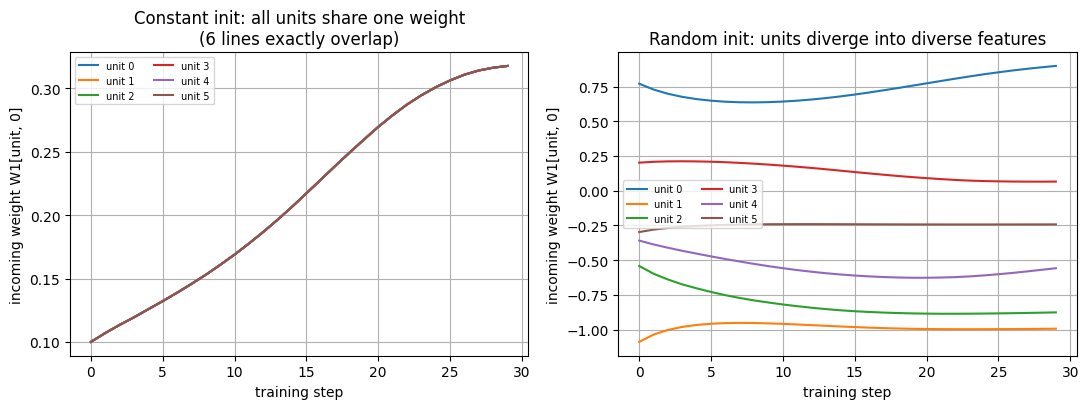

random init, max |unit0 - unit1| over steps: 1.8924224376678467


In [5]:
net_rand = TinyMLP(hidden=6).to(device)
init_net(net_rand, mode="random", std=0.5, seed=0)
Wr, Gr = train_track(net_rand, steps=30)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for j in range(Wc.shape[1]):
    axes[0].plot(Wc[:, j, 0].numpy(), label=f"unit {j}")
    axes[1].plot(Wr[:, j, 0].numpy(), label=f"unit {j}")
axes[0].set_title("Constant init: all units share one weight\n(6 lines exactly overlap)")
axes[1].set_title("Random init: units diverge into diverse features")
for ax in axes:
    ax.set_xlabel("training step")
    ax.set_ylabel("incoming weight W1[unit, 0]")
    ax.legend(fontsize=7, ncol=2, loc="best")
plt.tight_layout()
plt.show()

print("random init, max |unit0 - unit1| over steps:", (Wr[:, 0] - Wr[:, 1]).abs().max().item())

### Widget 1: symmetry vs broken symmetry

Toggle **random init** on and off. With constant init every hidden unit traces
the same curve (the lines overlap perfectly) in both weights and gradients: the
symmetry is never broken. Flip on random init and the units separate. The
`const_value` slider only matters when random init is off; try a few values and
notice the units stay glued together regardless.

In [6]:
def symmetry_demo(random_init=False, const_value=0.1, steps=40):
    net = TinyMLP(hidden=6).to(device)
    init_net(net, mode=("random" if random_init else "constant"),
             const=const_value, std=0.5, seed=0)
    W_hist, G_hist = train_track(net, steps=steps)

    mode = "random init (symmetry broken)" if random_init else \
           f"constant init = {const_value:.2f} (symmetric)"
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    for j in range(W_hist.shape[1]):
        axes[0].plot(W_hist[:, j, 0].numpy(), label=f"unit {j}")
        axes[1].plot(G_hist[:, j, 0].numpy(), label=f"unit {j}")
    axes[0].set_title("weight W1[unit, 0] over steps\n" + mode)
    axes[0].set_ylabel("weight value")
    axes[1].set_title("gradient dL / dW1[unit, 0] over steps\n" + mode)
    axes[1].set_ylabel("gradient value")
    for ax in axes:
        ax.set_xlabel("training step")
        ax.legend(fontsize=7, ncol=2, loc="best")
    plt.tight_layout()
    plt.show()


interact(symmetry_demo,
         random_init=Checkbox(value=False, description="random init"),
         const_value=FloatSlider(min=0.01, max=1.0, step=0.01, value=0.1),
         steps=IntSlider(min=5, max=80, step=5, value=40));

interactive(children=(Checkbox(value=False, description='random init'), FloatSlider(value=0.1, description='co…

## 2. How large should random weights be? A variance argument

Random init breaks the symmetry, but the **scale** still matters: weights that
are too large or too small make sigmoid / tanh saturate and gradients vanish.
The slide pins down the right scale with a short variance calculation.

Take a pre-activation $a_1 = \sum_{i=1}^{n} w_{i1}\, x_i$ with inputs of mean $0$
and variance $1$, and weights of mean $0$. Since the terms are independent and
zero-mean,

$$ \mathrm{Var}(a_1) = \sum_{i=1}^{n} \mathrm{Var}(w_{i1} x_i) = n\,\mathrm{Var}(w)\,\mathrm{Var}(x). $$

Stacking $k$ such layers multiplies this factor each time:

$$ \mathrm{Var}(a_k) = \big(n\,\mathrm{Var}(w)\big)^{k}\,\mathrm{Var}(x). $$

- If $n\,\mathrm{Var}(w) > 1$ the variance **explodes** with depth.
- If $n\,\mathrm{Var}(w) < 1$ it **vanishes** to zero.
- We need $n\,\mathrm{Var}(w) = 1$, i.e. draw $w$ from a standard normal and scale
  by $1/\sqrt{n}$, where $n$ is the fan-in.

We test this directly. Let $w \sim \mathcal{N}(0,\ \sigma^2)$ with
$\sigma = g / \sqrt{n}$ for a **gain** $g$. Then $n\,\mathrm{Var}(w) = g^2$, so the
per-layer variance follows $\mathrm{Var}(a_k) = g^{2k}$. The gain $g$ is the knob:
$g < 1$ vanishes, $g = 1$ is stable, $g > 1$ explodes.

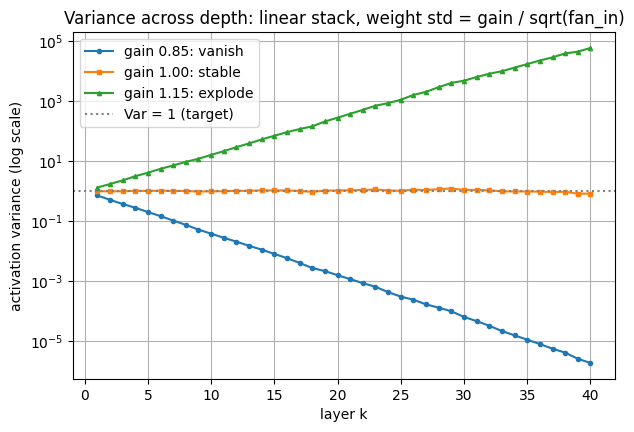

In [7]:
def layer_variances(gain, depth=40, width=128, batch=256, activation=None, seed=0):
    """Forward a zero-mean unit-variance batch through `depth` linear layers whose
    weights have std = gain / sqrt(fan_in). Return the activation variance per layer.
    Biases are 0 and fan_in = width, so n * Var(w) = gain**2 exactly."""
    torch.manual_seed(seed)
    a = torch.randn(batch, width, device=device)       # inputs ~ N(0, 1)
    std = gain / (width ** 0.5)
    variances = []
    for _ in range(depth):
        W = torch.randn(width, width, device=device) * std
        a = a @ W.t()
        if activation is not None:
            a = activation(a)
        variances.append(a.var(unbiased=False).item())
    return variances


depth = 40
fig, ax = plt.subplots()
for gain, style, name in [(0.85, "o-", "gain 0.85: vanish"),
                          (1.00, "s-", "gain 1.00: stable"),
                          (1.15, "^-", "gain 1.15: explode")]:
    v = layer_variances(gain, depth=depth)
    ax.semilogy(range(1, depth + 1), v, style, markersize=3, label=name)
ax.axhline(1.0, color="gray", ls=":", label="Var = 1 (target)")
ax.set_xlabel("layer k")
ax.set_ylabel("activation variance (log scale)")
ax.set_title("Variance across depth: linear stack, weight std = gain / sqrt(fan_in)")
ax.legend(loc="best")
plt.show()

### Widget 2: watch variance explode or vanish

Move **gain** and **depth**. The measured per-layer variance (dots) tracks the
theory line $g^{2k}$ (dashed) almost perfectly. Push the gain a little above $1$
and even a moderate depth blows the variance up by many orders of magnitude; drop
it below $1$ and the signal dies. Only $g = 1$, that is $\sigma = 1/\sqrt{n}$,
keeps the variance flat.

In [8]:
def variance_widget(gain=1.10, depth=30):
    v = layer_variances(gain, depth=depth, width=128, batch=256)
    theory = [gain ** (2 * k) for k in range(1, depth + 1)]

    fig, ax = plt.subplots()
    ax.semilogy(range(1, depth + 1), v, "o-", markersize=3, label="measured variance")
    ax.semilogy(range(1, depth + 1), theory, "k--", label=r"theory  $g^{2k}$")
    ax.axhline(1.0, color="gray", ls=":", label="Var = 1 (stable)")
    ax.set_xlabel("layer k")
    ax.set_ylabel("activation variance (log scale)")
    ax.set_title(f"gain g = {gain:.2f},  n Var(w) = g^2 = {gain ** 2:.3f}")
    ax.legend(loc="best")
    plt.show()


interact(variance_widget,
         gain=FloatSlider(min=0.5, max=1.5, step=0.02, value=1.10),
         depth=IntSlider(min=5, max=50, step=1, value=30));

interactive(children=(FloatSlider(value=1.1, description='gain', max=1.5, min=0.5, step=0.02), IntSlider(value…

## 3. Xavier / Glorot and He initialization, from scratch

The $1/\sqrt{n}$ rule balances the **forward** pass. Glorot and Bengio (2010)
noted the **backward** pass wants $\mathrm{Var}(w) = 1/\text{fan\_out}$ too, so they
split the difference and use the average:

$$ \mathrm{Var}(w) = \frac{2}{\text{fan\_in} + \text{fan\_out}}. $$

**Xavier / Glorot (uniform).** For $w \sim \mathrm{Uniform}[-a, a]$ we have
$\mathrm{Var}(w) = a^2 / 3$. Setting that equal to $2 / (\text{fan\_in} + \text{fan\_out})$
gives

$$ a = \sqrt{\frac{6}{\text{fan\_in} + \text{fan\_out}}}, \qquad w \sim \mathrm{Uniform}\!\left(-a,\ a\right). $$

This is exactly the slide's $\mathrm{Uniform}\!\big(-\sqrt{6}/\sqrt{\text{fan\_in}+\text{fan\_out}},\ +\sqrt{6}/\sqrt{\text{fan\_in}+\text{fan\_out}}\big)$.

**He (Kaiming).** With ReLU, roughly half the pre-activations are zeroed, which
halves the variance. To compensate, He et al. (2015) target twice the variance,
$\mathrm{Var}(w) = 2 / \text{fan\_in}$, i.e. the **He normal**

$$ w \sim \mathcal{N}\!\left(0,\ \frac{2}{\text{fan\_in}}\right), \qquad \sigma = \sqrt{\frac{2}{\text{fan\_in}}}. $$

He init is the one to use for ReLU networks. (Historical aside from the slide:
before these formulas, deep nets were bootstrapped with greedy layerwise
*unsupervised pretraining*, Hinton 2006; good initializers replaced it.)
We code both from scratch and check them against `torch.nn.init`.

In [9]:
def xavier_uniform_init(fan_in, fan_out):
    """Xavier / Glorot uniform: w ~ Uniform(-a, a), a = sqrt(6 / (fan_in + fan_out))."""
    a = (6.0 / (fan_in + fan_out)) ** 0.5
    return (torch.rand(fan_out, fan_in) * 2.0 - 1.0) * a     # shape (out, in), like nn.Linear


def he_normal_init(fan_in, fan_out):
    """He / Kaiming normal for ReLU: w ~ N(0, 2 / fan_in)."""
    std = (2.0 / fan_in) ** 0.5
    return torch.randn(fan_out, fan_in) * std


# Verify our formulas against torch.nn.init on a (fan_out=64, fan_in=128) weight.
torch.manual_seed(0)
w = torch.empty(64, 128)

nn.init.xavier_uniform_(w)
print("Xavier uniform bound a:")
print("  ours  sqrt(6/(128+64)) =", round((6.0 / (128 + 64)) ** 0.5, 5))
print("  torch max |w|          =", round(w.abs().max().item(), 5))

nn.init.kaiming_normal_(w, nonlinearity="relu")      # He normal, fan_in mode
print("He normal std:")
print("  ours  sqrt(2/128)      =", round((2.0 / 128) ** 0.5, 5))
print("  torch empirical std    =", round(w.std().item(), 5))

Xavier uniform bound a:
  ours  sqrt(6/(128+64)) = 0.17678
  torch max |w|          = 0.17675
He normal std:
  ours  sqrt(2/128)      = 0.125
  torch empirical std    = 0.12582


Now compare all the schemes on a **deep ReLU stack**. This is where the ReLU
correction bites: plain $1/\sqrt{n}$ (which is what Xavier reduces to for square
layers) loses about half the variance per ReLU layer and slowly vanishes, while
He is tuned to hold it flat. The naive too-small and too-large inits vanish and
explode as in section 2.

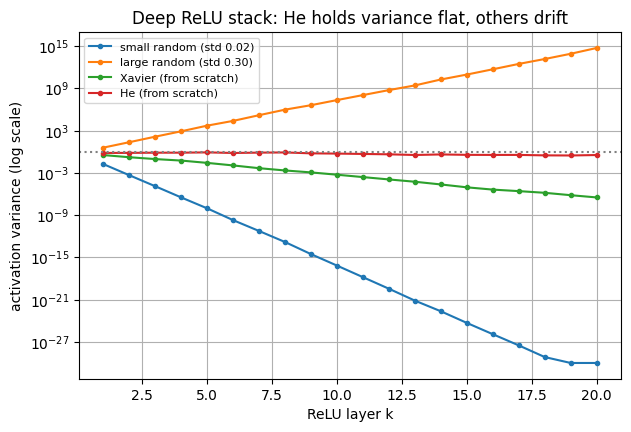

In [10]:
def relu_net_variances(init_fn, depth=20, width=128, batch=256, seed=0):
    """Per-layer activation variance for a ReLU stack initialized by init_fn(fan_in, fan_out)."""
    torch.manual_seed(seed)
    a = torch.randn(batch, width, device=device)
    variances = []
    for _ in range(depth):
        W = init_fn(width, width).to(device)
        a = torch.relu(a @ W.t())
        variances.append(a.var(unbiased=False).item())
    return variances


schemes = {
    "small random (std 0.02)": lambda fi, fo: torch.randn(fo, fi) * 0.02,
    "large random (std 0.30)": lambda fi, fo: torch.randn(fo, fi) * 0.30,
    "Xavier (from scratch)":   xavier_uniform_init,
    "He (from scratch)":       he_normal_init,
}

depth = 20
fig, ax = plt.subplots()
for name, fn in schemes.items():
    v = relu_net_variances(fn, depth=depth)
    ax.semilogy(range(1, depth + 1), [max(x, 1e-30) for x in v], "o-", markersize=3, label=name)
ax.axhline(1.0, color="gray", ls=":")
ax.set_xlabel("ReLU layer k")
ax.set_ylabel("activation variance (log scale)")
ax.set_title("Deep ReLU stack: He holds variance flat, others drift")
ax.legend(loc="best", fontsize=8)
plt.show()

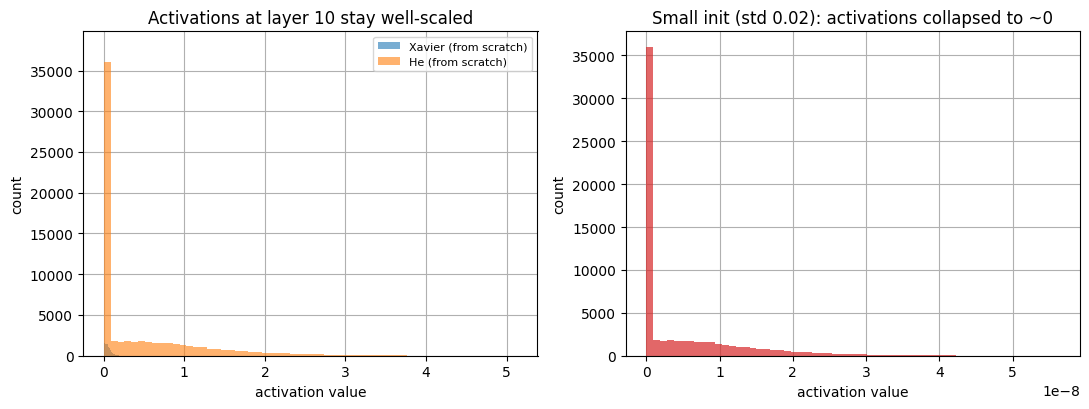

In [11]:
# Histograms of the activations at a deep layer: Xavier and He stay well-scaled,
# while the naive inits have collapsed or blown up.
def deep_layer_activations(init_fn, depth=10, width=128, batch=512, seed=1):
    torch.manual_seed(seed)
    a = torch.randn(batch, width, device=device)
    for _ in range(depth):
        W = init_fn(width, width).to(device)
        a = torch.relu(a @ W.t())
    return a.flatten().cpu().numpy()


fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for name, fn in [("Xavier (from scratch)", xavier_uniform_init),
                 ("He (from scratch)", he_normal_init)]:
    acts = deep_layer_activations(fn)
    axes[0].hist(acts, bins=60, alpha=0.6, label=f"{name}")
axes[0].set_title("Activations at layer 10 stay well-scaled")
axes[0].set_xlabel("activation value"); axes[0].set_ylabel("count")
axes[0].legend(loc="best", fontsize=8)

small = deep_layer_activations(lambda fi, fo: torch.randn(fo, fi) * 0.02)
axes[1].hist(small, bins=60, color="tab:red", alpha=0.7)
axes[1].set_title("Small init (std 0.02): activations collapsed to ~0")
axes[1].set_xlabel("activation value"); axes[1].set_ylabel("count")
plt.tight_layout()
plt.show()

### Widget 3: initialization method vs training

Pick an **init method** for a 5-hidden-layer ReLU classifier on the moons data.
The left panel shows the per-layer activation variance *at initialization* (log
scale); the right panel shows the training loss for a short run. Watch:
- **zeros**: symmetry, the variance is $0$ and the loss barely moves.
- **small-random / large-random**: variance vanishes or explodes; training is slow or unstable.
- **Xavier / He**: variance stays sane and the loss drops smoothly.

In [12]:
class DeepMLP(nn.Module):
    """A few ReLU hidden layers then a linear output. Can report per-layer activations."""
    def __init__(self, in_dim=2, width=32, n_hidden=5, out_dim=1):
        super().__init__()
        self.hidden = nn.ModuleList()
        d = in_dim
        for _ in range(n_hidden):
            self.hidden.append(nn.Linear(d, width))
            d = width
        self.out = nn.Linear(d, out_dim)

    def forward(self, x, return_acts=False):
        acts = []
        for lin in self.hidden:
            x = torch.relu(lin(x))
            acts.append(x)
        out = self.out(x)
        return (out, acts) if return_acts else out


def apply_init(net, method):
    """Set every Linear weight by the chosen scheme; biases to 0."""
    with torch.no_grad():
        for m in net.modules():
            if isinstance(m, nn.Linear):
                fi, fo = m.in_features, m.out_features
                if method == "zeros":
                    m.weight.zero_()
                elif method == "small-random":
                    m.weight.normal_(0.0, 0.02)
                elif method == "large-random":
                    m.weight.normal_(0.0, 0.30)
                elif method == "Xavier":
                    m.weight.copy_(xavier_uniform_init(fi, fo).to(m.weight.device))
                elif method == "He":
                    m.weight.copy_(he_normal_init(fi, fo).to(m.weight.device))
                m.bias.zero_()


def train_moons(net, lr=0.2, steps=150):
    opt = torch.optim.SGD(net.parameters(), lr=lr)
    losses = []
    for _ in range(steps):
        opt.zero_grad()
        loss = F.binary_cross_entropy_with_logits(net(X_moons), y_moons)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses


def init_task_demo(method="He"):
    torch.manual_seed(0)
    net = DeepMLP(width=32, n_hidden=5).to(device)
    apply_init(net, method)
    with torch.no_grad():
        _, acts = net(X_moons, return_acts=True)
    variances = [max(a.var(unbiased=False).item(), 1e-12) for a in acts]
    losses = train_moons(net, lr=0.2, steps=150)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    axes[0].semilogy(range(1, len(variances) + 1), variances, "o-")
    axes[0].axhline(1.0, color="gray", ls=":")
    axes[0].set_xlabel("hidden layer"); axes[0].set_ylabel("activation variance (log)")
    axes[0].set_title(f"variance at init: {method}")
    axes[1].plot(losses)
    axes[1].set_xlabel("training step"); axes[1].set_ylabel("BCE loss")
    axes[1].set_title(f"training loss: {method}")
    axes[1].set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()


interact(init_task_demo,
         method=Dropdown(options=["zeros", "small-random", "large-random", "Xavier", "He"],
                         value="He"));

interactive(children=(Dropdown(description='method', index=4, options=('zeros', 'small-random', 'large-random'…

## 4. Batch Normalization from scratch

Good initialization sets the activations up well at step $0$, but training keeps
shifting them. **Covariate shift** is a change in input distribution between two
scenarios; inside a network, the input distribution to a layer keeps changing as
the layers below update. This is **internal covariate shift**, and it slows
training because every layer must chase a moving target.

**Batch Normalization** (Ioffe and Szegedy, 2015) fixes each layer's input
distribution. For a feature $x^{(k)}$, using the mean and variance over the
current mini-batch:

$$ \hat{x}^{(k)} = \frac{x^{(k)} - \mathrm{E}[x^{(k)}]}{\sqrt{\mathrm{Var}[x^{(k)}] + \epsilon}}. $$

Forcing every layer's input to be a unit Gaussian is too rigid, so BN adds two
**learnable** parameters per feature, $\gamma^{(k)}$ and $\beta^{(k)}$, letting the
network pick a better scale and shift:

$$ y^{(k)} = \gamma^{(k)} \hat{x}^{(k)} + \beta^{(k)}. $$

We build the forward pass from scratch and check it re-centers a skewed batch.

In [13]:
def batchnorm_forward(x, gamma, beta, eps=1e-5):
    """BN forward for a batch x of shape (N, D): normalize each feature (column)
    over the batch, then apply per-feature scale gamma and shift beta.
    Returns (y, x_hat) where x_hat is the normalized value before gamma / beta."""
    mu = x.mean(dim=0, keepdim=True)                    # per-feature mean over the batch
    var = x.var(dim=0, unbiased=False, keepdim=True)    # per-feature variance (biased)
    x_hat = (x - mu) / torch.sqrt(var + eps)
    return gamma * x_hat + beta, x_hat


# A deliberately skewed, off-center batch of 4 features.
torch.manual_seed(0)
skewed = 3.0 * torch.randn(512, 4, device=device) + 5.0     # mean ~5, std ~3
skewed[:, 0] = torch.exp(0.5 * skewed[:, 0] / 5.0)          # feature 0 is heavy-tailed

gamma = torch.ones(4, device=device)
beta = torch.zeros(4, device=device)
y_bn, x_hat = batchnorm_forward(skewed, gamma, beta)

print("before BN: per-feature mean =", skewed.mean(0).cpu().numpy().round(2))
print("           per-feature std  =", skewed.std(0).cpu().numpy().round(2))
print("after  BN (x_hat, gamma=1, beta=0):")
print("           per-feature mean =", x_hat.mean(0).cpu().numpy().round(3))
print("           per-feature std  =", x_hat.std(0).cpu().numpy().round(3))

before BN: per-feature mean = [1.71 5.23 5.05 4.97]
           per-feature std  = [0.54 3.14 3.06 3.09]
after  BN (x_hat, gamma=1, beta=0):
           per-feature mean = [-0. -0. -0. -0.]
           per-feature std  = [1.001 1.001 1.001 1.001]


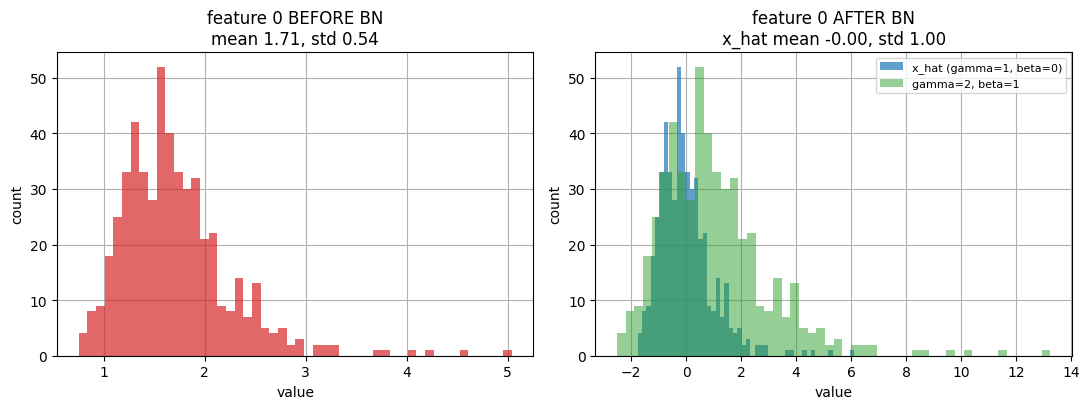

In [14]:
# Show the re-centering and re-scaling on one skewed feature.
f = 0
before = skewed[:, f].cpu().numpy()
after = x_hat[:, f].cpu().numpy()
rescaled = (2.0 * x_hat[:, f] + 1.0).cpu().numpy()          # gamma = 2, beta = 1

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(before, bins=50, color="tab:red", alpha=0.7)
axes[0].set_title(f"feature {f} BEFORE BN\nmean {before.mean():.2f}, std {before.std():.2f}")
axes[0].set_xlabel("value"); axes[0].set_ylabel("count")

axes[1].hist(after, bins=50, color="tab:blue", alpha=0.7, label="x_hat (gamma=1, beta=0)")
axes[1].hist(rescaled, bins=50, color="tab:green", alpha=0.5, label="gamma=2, beta=1")
axes[1].set_title(f"feature {f} AFTER BN\nx_hat mean {after.mean():.2f}, std {after.std():.2f}")
axes[1].set_xlabel("value"); axes[1].set_ylabel("count")
axes[1].legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

### From scratch vs `nn.BatchNorm1d`, and the test-time rule

The BN layer behaves **differently at test time**. During training it uses the
mini-batch mean and variance, but it also keeps a **running average** of them; at
test time it uses those fixed running statistics instead of the test batch (so a
single test example is normalized consistently). PyTorch normalizes with the
*biased* batch variance but updates the running estimate with the *unbiased*
variance. We match both and check against `nn.BatchNorm1d`.

In [15]:
class BatchNorm1dScratch:
    """Minimal BN over features, matching nn.BatchNorm1d semantics:
    normalize with the biased batch variance, update running stats with the
    unbiased variance. Keeps running_mean / running_var for test time."""
    def __init__(self, dim, momentum=0.1, eps=1e-5):
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
        self.momentum = momentum
        self.eps = eps

    def __call__(self, x, training=True):
        if training:
            mu = x.mean(0)
            var_biased = x.var(0, unbiased=False)
            var_unbiased = x.var(0, unbiased=True)
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mu
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * var_unbiased
            x_hat = (x - mu) / torch.sqrt(var_biased + self.eps)
        else:                                            # test time: use running stats
            x_hat = (x - self.running_mean) / torch.sqrt(self.running_var + self.eps)
        return self.gamma * x_hat + self.beta


# Feed the same batches to our BN and to nn.BatchNorm1d, then compare.
torch.manual_seed(1)
scratch_bn = BatchNorm1dScratch(4, momentum=0.1)
ref_bn = nn.BatchNorm1d(4, momentum=0.1, affine=False)   # affine=False -> gamma=1, beta=0
ref_bn.train()

max_train_diff = 0.0
for _ in range(20):
    xb = 2.0 * torch.randn(32, 4) + 4.0
    out_ours = scratch_bn(xb, training=True)
    out_ref = ref_bn(xb)
    max_train_diff = max(max_train_diff, (out_ours - out_ref).abs().max().item())

print("train-mode output   max diff (ours vs torch):", max_train_diff)
print("running_mean         max diff:", (scratch_bn.running_mean - ref_bn.running_mean).abs().max().item())
print("running_var          max diff:", (scratch_bn.running_var - ref_bn.running_var).abs().max().item())

# Test time: both use the running statistics, not the test batch.
ref_bn.eval()
x_test = 2.0 * torch.randn(32, 4) + 4.0
eval_diff = (scratch_bn(x_test, training=False) - ref_bn(x_test)).abs().max().item()
print("eval-mode output     max diff:", eval_diff)

train-mode output   max diff (ours vs torch): 7.152557373046875e-07
running_mean         max diff: 2.384185791015625e-07
running_var          max diff: 2.384185791015625e-07
eval-mode output     max diff: 4.76837158203125e-07


### BN in training: higher learning rates without blowing up

The slide lists BN's benefits: it **allows higher learning rates** (no fear of
exploding activations), **reduces the dependence on initialization**, and **acts
as a regularizer**. BN is usually inserted **before** the non-linearity, so each
block is Linear then BN then ReLU. We train the same deep MLP with and without BN
at a deliberately high learning rate and compare stability.

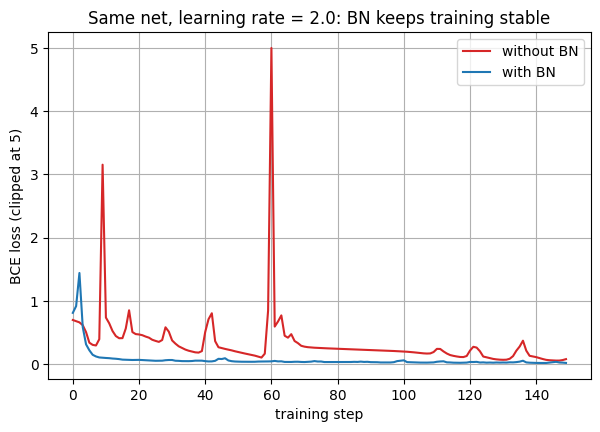

In [16]:
class MLPBN(nn.Module):
    """Deep MLP; each hidden block is Linear -> (BN) -> ReLU. BN before the activation."""
    def __init__(self, in_dim=2, width=64, n_hidden=4, out_dim=1, use_bn=False):
        super().__init__()
        layers, d = [], in_dim
        for _ in range(n_hidden):
            layers.append(nn.Linear(d, width))
            if use_bn:
                layers.append(nn.BatchNorm1d(width))     # inserted before ReLU
            layers.append(nn.ReLU())
            d = width
        layers.append(nn.Linear(d, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_bn(use_bn, lr, steps=150, seed=0):
    torch.manual_seed(seed)
    net = MLPBN(use_bn=use_bn).to(device)
    net.train()
    opt = torch.optim.SGD(net.parameters(), lr=lr)
    losses = []
    for _ in range(steps):
        opt.zero_grad()
        loss = F.binary_cross_entropy_with_logits(net(X_moons), y_moons)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses


high_lr = 2.0
loss_no_bn = train_bn(use_bn=False, lr=high_lr)
loss_bn = train_bn(use_bn=True, lr=high_lr)

fig, ax = plt.subplots()
ax.plot(np.clip(loss_no_bn, 0, 5), color="tab:red", label="without BN")
ax.plot(np.clip(loss_bn, 0, 5), color="tab:blue", label="with BN")
ax.set_xlabel("training step"); ax.set_ylabel("BCE loss (clipped at 5)")
ax.set_title(f"Same net, learning rate = {high_lr}: BN keeps training stable")
ax.legend(loc="best")
plt.show()

### Widget 4: BN on/off and the learning rate

Toggle **batch norm** and drag the **learning rate**. Without BN, a high learning
rate makes the loss oscillate or diverge (it hits the clip ceiling at $5$). Turn
BN on and the same high rate trains smoothly. This is the practical payoff of
keeping activations well-scaled throughout training.

In [17]:
def bn_demo(batch_norm=False, lr=1.5):
    losses = train_bn(use_bn=batch_norm, lr=lr)
    fig, ax = plt.subplots()
    color = "tab:blue" if batch_norm else "tab:red"
    ax.plot(np.clip(losses, 0, 5), color=color,
            label=("with BN" if batch_norm else "without BN"))
    ax.set_xlabel("training step"); ax.set_ylabel("BCE loss (clipped at 5)")
    ax.set_ylim(0, 5)
    ax.set_title(f"BN = {'on' if batch_norm else 'off'},  learning rate = {lr:.2f}")
    ax.legend(loc="best")
    plt.show()


interact(bn_demo,
         batch_norm=Checkbox(value=False, description="batch norm"),
         lr=FloatSlider(min=0.1, max=3.0, step=0.1, value=1.5));

interactive(children=(Checkbox(value=False, description='batch norm'), FloatSlider(value=1.5, description='lr'…

## Key takeaways

- **Where you start matters.** On a non-convex error surface, initialization
  decides which minimum is reachable.
- **Constant / zero init is fatal.** All hidden units in a layer compute the same
  thing and receive identical gradients, so they stay identical and the layer can
  never learn diverse features. Random init breaks this symmetry.
- **Scale is set by variance.** With $\mathrm{Var}(a_k) = (n\,\mathrm{Var}(w))^k\,\mathrm{Var}(x)$,
  activations explode if $n\,\mathrm{Var}(w) > 1$ and vanish if $< 1$. Choosing
  $n\,\mathrm{Var}(w) = 1$, i.e. weight std $1/\sqrt{n}$ (fan-in $n$), keeps them stable.
- **Xavier** averages the forward and backward constraints:
  $\mathrm{Uniform}(\pm\sqrt{6 / (\text{fan\_in}+\text{fan\_out})})$. **He** adds the ReLU
  factor of $2$: $\mathcal{N}(0,\ 2/\text{fan\_in})$. Both matched `torch.nn.init`.
- **Batch Normalization** normalizes each feature over the mini-batch to zero mean
  and unit variance, then rescales with learnable $\gamma, \beta$ (usually before
  the activation). It allows higher learning rates, reduces dependence on
  initialization, and regularizes. At **test time** it uses running averages of
  the training statistics, not the test batch.
- **One theme.** Good initialization and Batch Normalization are two ways to do
  the same job: keep activations (and therefore gradients) well-scaled, at step
  $0$ and throughout training.

## Exercises

- **Derive He initialization** yourself: redo the section 2 variance argument but put
  a ReLU after each layer. Show that ReLU roughly halves the variance, so you need
  $\mathrm{Var}(w) = 2/\text{fan\_in}$. Verify with `relu_net_variances` above.
- **Show BN is differentiable.** For a single hidden layer, work out the backprop
  gradients for $\gamma$ and $\beta$ (and for $\hat{x}$). Then confirm numerically
  that `torch.autograd` produces the same gradients through `batchnorm_forward`.
- Revisit Widget 3 and Widget 4 together: can a good initializer alone match BN at
  a high learning rate, or does BN still help?